In [1]:
import os
import math
import pandas as pd
import numpy as np
import random
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import pickle
import tqdm
%matplotlib inline
from IPython.display import clear_output
from typing import List, Tuple, Optional
import matplotlib.ticker as mticker


os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'

# data_folder = "drive/MyDrive/mestrado_final_files/data/"
# models_time_folder = "drive/MyDrive/mestrado_final_files/models/SpentTimeModel_MultiTowers/"
# models_token_metrics_folder = "drive/MyDrive/mestrado_final_files/metrics_models/NGramModel_ExtraInfo_MultiTowers/"

data_folder = "G:\Meu Drive\mestrado_final_files\data\\"
models_time_folder = "G:\Meu Drive\mestrado_final_files\models\\SpentTimeModel_MultiTowers\\"
models_token_metrics_folder = "G:\Meu Drive\mestrado_final_files\metrics_models\\NGramModel_ExtraInfo_MultiTowers\\"

#models_time_folder = "G:\Meu Drive\mestrado_final_files\models\\SpentTimeModel\\"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [2]:
# from google.colab import drive
# drive.mount('/content/drive')

In [3]:
def get_vectorized_murphy(y_true_multiclasse, y_prob_matriz, top_n=600, n_bins=10):
    """
    Calcula as métricas de Murphy de forma vetorizada, corrigindo o
    shape de arrays dinâmicos e espelhando a discretização exata do pd.cut.
    """
    N_amostras = len(y_true_multiclasse)
    if N_amostras == 0:
        return pd.DataFrame()

    # 1. Identificar Top Tokens presentes estritamente neste slice
    tokens, counts = np.unique(y_true_multiclasse, return_counts=True)
    sort_idx = np.argsort(-counts)

    top_tokens_ids = tokens[sort_idx][:top_n]
    top_counts = counts[sort_idx][:top_n]

    # A CORREÇÃO CRÍTICA DO SHAPE:
    actual_n = len(top_tokens_ids)

    # 2. Isolar matrizes para os tokens filtrados
    P = y_prob_matriz[:, top_tokens_ids]
    Y = (y_true_multiclasse[:, None] == top_tokens_ids).astype(float)

    # 3. Taxas Base e Incerteza
    base_rates = Y.mean(axis=0)
    uncertainty = base_rates * (1 - base_rates)

    # 4. Discretização exata equivalente ao pd.cut(include_lowest=True)
    bin_edges = np.linspace(0, 1, n_bins + 1)
    # digitize com right=True aloca valores <= à borda direita do bin
    bins = np.digitize(P, bin_edges[1:], right=True)
    bins = np.clip(bins, 0, n_bins - 1)

    # Vetores dimensionados corretamente para o slice atual
    resolution = np.zeros(actual_n)
    reliability = np.zeros(actual_n)

    for b in range(n_bins):
        mask = (bins == b) # booleano (N_amostras, actual_n)
        bin_counts = mask.sum(axis=0)

        valid = bin_counts > 0

        prob_mean = np.zeros(actual_n)
        # np.where é mais seguro e direto que multiplicar float por bool
        prob_mean[valid] = np.where(mask, P, 0.0).sum(axis=0)[valid] / bin_counts[valid]

        true_fraction = np.zeros(actual_n)
        true_fraction[valid] = np.where(mask, Y, 0.0).sum(axis=0)[valid] / bin_counts[valid]

        weight = bin_counts / N_amostras
        reliability[valid] += weight[valid] * (prob_mean[valid] - true_fraction[valid])**2
        resolution[valid] += weight[valid] * (true_fraction[valid] - base_rates[valid])**2

    brier_score = reliability - resolution + uncertainty

    return pd.DataFrame({
        'token_id': top_tokens_ids,
        'frequencia': top_counts,
        'brier_score_multinomial': brier_score,
        'reliability_erro': reliability,
        'resolution_poder': resolution,
        'uncertainty_caos': uncertainty
    })

def get_vectorized_murphy_all_classes(
    y_true_multiclasse,
    y_prob_matriz,
    classes=None,
    n_bins=10
):
    """
    Calcula a decomposição de Murphy considerando todas as classes possíveis.
    Isso evita perder reliability de classes não observadas no y_true do grupo,
    mas que receberam probabilidade positiva do modelo.
    """
    N_amostras = len(y_true_multiclasse)

    if N_amostras == 0:
        return pd.DataFrame()

    if classes is None:
        classes = np.arange(y_prob_matriz.shape[1])

    classes = np.asarray(classes)

    P = y_prob_matriz[:, classes]
    Y = (y_true_multiclasse[:, None] == classes).astype(float)

    base_rates = Y.mean(axis=0)
    uncertainty = base_rates * (1 - base_rates)

    bin_edges = np.linspace(0, 1, n_bins + 1)
    bins = np.digitize(P, bin_edges[1:], right=True)
    bins = np.clip(bins, 0, n_bins - 1)

    actual_n = len(classes)

    resolution = np.zeros(actual_n)
    reliability = np.zeros(actual_n)

    for b in range(n_bins):
        mask = bins == b
        bin_counts = mask.sum(axis=0)

        valid = bin_counts > 0

        prob_mean = np.zeros(actual_n)
        true_fraction = np.zeros(actual_n)

        prob_mean[valid] = np.where(mask, P, 0.0).sum(axis=0)[valid] / bin_counts[valid]
        true_fraction[valid] = np.where(mask, Y, 0.0).sum(axis=0)[valid] / bin_counts[valid]

        weight = bin_counts / N_amostras

        reliability[valid] += weight[valid] * (prob_mean[valid] - true_fraction[valid]) ** 2
        resolution[valid] += weight[valid] * (true_fraction[valid] - base_rates[valid]) ** 2

    brier_decomp = reliability - resolution + uncertainty

    frequencia = Y.sum(axis=0).astype(int)

    return pd.DataFrame({
        "token_id": classes,
        "frequencia": frequencia,
        "brier_score_multinomial": brier_decomp,
        "reliability_erro": reliability,
        "resolution_poder": resolution,
        "uncertainty_caos": uncertainty
    })

In [4]:
%run 01_functions_training.ipynb
#%run drive/MyDrive/mestrado_final_files/notebooks/01_functions_training.ipynb

In [5]:
with open(data_folder + 'data_time_features.pkl', 'rb') as f:
    df_time_features = pickle.load(f)

In [6]:
with open(data_folder + 'dict_set_covariables.pkl', 'rb') as f:
    dict_set_covariables = pickle.load(f)

In [7]:
list_models = [item for item in os.listdir(models_time_folder) if "SpentTimeModel_" in item and ".pth" in item]

In [8]:
VOCAB_SIZE = 601
TIME_SIZE = 301

In [9]:
def get_match_splits(df, num_secs = 300):
    num_breaks = [i for i in range(0, 7201, num_secs)]
    num_labels = [str(i) + "-" + str(j) for i, j in zip(num_breaks[:-1], num_breaks[1:])]
    num_breaks[0] -= 1
    num_breaks[-1] += 1
    return df.assign(cat_time = lambda df: pd.cut(df["remaining_time"], bins = num_breaks, labels = num_labels))

def multiclass_cross_entropy(y_true, y_prob, eps=1e-15):
    y_prob = np.clip(y_prob, eps, 1 - eps)
    return -np.mean(np.log(y_prob[np.arange(len(y_true)), y_true]))

def process_group(idx, dev_y, all_probs, classes = None, get_bs_global = False, get_ce = False, get_mae = False):
    y_true_sub = dev_y[idx]
    y_prob_sub = all_probs[idx]

    if classes is None:
        classes = np.arange(y_prob_sub.shape[1])

    df_res = get_vectorized_murphy_all_classes(y_true_multiclasse=y_true_sub, y_prob_matriz = y_prob_sub, classes = classes, n_bins = 10)

    if get_bs_global:
        bs_global = multiclass_brier_score(y_true = y_true_sub, y_prob = y_prob_sub)
        df_res["brier_score_multinomial"] = bs_global

    if get_ce:
        ce_global = multiclass_cross_entropy(y_true = y_true_sub, y_prob = y_prob_sub)
        df_res["cross_entropy"] = ce_global

    if get_mae:
        expected_output = y_prob_sub @ np.arange(y_prob_sub.shape[1])
        mae_global = np.mean(np.abs(y_true_sub - expected_output))
        df_res["mae"] = mae_global

    return df_res

def multiclass_brier_score(y_true, y_prob):
    """
    Calcula o Brier Score Global para classificação multiclasse.
    
    y_true: array 1D com os índices reais dos tokens, shape (N,)
    y_prob: array 2D com as probabilidades preditas (softmax), shape (N, C)
    """
    N_amostras, n_classes = y_prob.shape
    
    # Cria a representação one-hot dos alvos (0.0 para erro, 1.0 para acerto)
    y_true_one_hot = np.zeros_like(y_prob, dtype=float)
    y_true_one_hot[np.arange(N_amostras), y_true] = 1.0
    
    # Calcula o erro quadrático, soma por classe e tira a média por amostra
    brier_score = np.mean(np.sum((y_prob - y_true_one_hot)**2, axis=1))
    
    return brier_score    

In [10]:
def format_time_seconds(x, pos=None):
    x = int(round(x))
    minutes = x // 60
    seconds = x % 60
    return f"{minutes}:{seconds:02d}"


In [11]:
list_decomposition_time = []
list_decomposition_dif = []
list_decomposition_time_dif = []
list_decomposition_season = []

group_variables1 = ["period", "cat_time", "context_size", "embedding_layer_size", "set_covariables", "num_hidden_neurons", "num_layers", "dropout_rate", "layer_norm"]
group_variables2 = ["cat_dif", "context_size", "embedding_layer_size", "set_covariables", "num_hidden_neurons", "num_layers", "dropout_rate", "layer_norm"]
group_variables3 = ["period", "cat_time", "cat_dif", "context_size", "embedding_layer_size", "set_covariables", "num_hidden_neurons", "num_layers", "dropout_rate", "layer_norm"]
group_variables4 = ["context_size", "embedding_layer_size", "set_covariables", "num_hidden_neurons", "num_layers", "dropout_rate", "layer_norm"]

num_classes = 301
for season in ["2018-19", "2019-20", "2020-21", "2021-22", "2022-23"]:
    str_season = season.replace("-", "")
    list_models = [item for item in os.listdir(models_time_folder) if "SpentTimeModel" in item and ".pth" in item and str_season in item]

    # 1. PREPARAÇÃO DOS DADOS DA TEMPORADA (FORA DO LOOP DE MODELOS)
    df_ = df_time_features.query("season == @season").query("season_split == 'dev'")

    # Processamento temporal feito uma única vez por temporada
    df_ = (df_
           .assign(period = lambda df: np.where(df["period"] > 4, 5, df["period"]))
           .pipe(get_match_splits, num_secs = 200))\
    .assign(cat_time = lambda df: df["cat_time"].astype("str"))\
    .assign(cat_dif = lambda df: df["token_state"] % 9)

    # Conversão eficiente de memória
    dev_tkn = torch.from_numpy(np.stack(df_["token_features"].values)).to(torch.int64)
    dev_num = torch.from_numpy(np.stack(df_["numerical_features"].values)).to(torch.float32) # Numéricas geralmente usam float32
    dev_stt = torch.from_numpy(np.asarray(df_["token_state"].to_list())).to(torch.int64)
    dev_y = df_["target_time"].values
    dev_mask = torch.tensor(build_logit_mask_spent_time_models(df_), dtype = torch.bool, device = device)

    print(season)
    for model_filename in tqdm.tqdm(list_models):

        CONTEXT_SIZE = int(model_filename.split("_context")[1].split("_")[0])
        EMBEDDING_LAYER_SIZE = int(model_filename.split("_embedding")[1].split("_")[0])
        variables_config = int(model_filename.split("_setcovariables")[1].split("_")[0])
        num_hidden_neurons = int(model_filename.split("_numneurons")[1].split("_")[0])
        num_layers = int(model_filename.split("_numlayers")[1].split("_")[0])
        dropout_rate = 0 if "nodropout" in model_filename else int(model_filename.split("_dropout")[1].split("_")[0]) / 10
        layer_norm = True if model_filename.split("_layernorm")[1].split("_")[0] == 'True' else False

        index_num_covariables1 = dict_set_covariables["index"][5]
        num_covariables1 = dict_set_covariables["covariables"][5]

        index_num_covariables2 = dict_set_covariables["index"][6]
        num_covariables2 = dict_set_covariables["covariables"][6]

        time_model = SpentTimeModel_MultiTowers(context_size = CONTEXT_SIZE, vocab_size = VOCAB_SIZE, time_size = TIME_SIZE, 
                                                embedding_dim = EMBEDDING_LAYER_SIZE, numeric_input_dims = [len(index_num_covariables1), len(index_num_covariables2)],
                                                token_tower_dim = 32, numeric_tower_dims = 16, num_hidden_neurons = num_hidden_neurons, 
                                                num_layers = num_layers, activation_function = nn.GELU, dropout_rate = dropout_rate, 
                                                use_layer_norm = layer_norm)
    
        time_model.load_state_dict(torch.load(models_time_folder + model_filename, weights_only = True, map_location = torch.device('cpu')))
        time_model.eval()

        # 2. INFERÊNCIA
        with torch.no_grad():
            # Ajuste condicional para modelos que requerem variáveis numéricas
            output_model = time_model(dev_tkn[:, -CONTEXT_SIZE:], [dev_num[:, index_num_covariables1], dev_num[:, index_num_covariables2]])
            output_model = output_model.masked_fill(dev_mask, -1e9)
            all_probs = torch.softmax(output_model, dim = 1).cpu().numpy()

        # 3. EXTRAÇÃO POR TEMPO
        results_time = []
        for name, group_idx in df_.groupby(["season_split", "period", "cat_time"], observed = True).indices.items():
            res_df = process_group(idx = group_idx, dev_y = dev_y, all_probs = all_probs, get_bs_global = True, get_ce = True, get_mae = True)
            res_df["season_split"] = name[0]
            res_df["period"] = name[1]
            res_df["cat_time"] = name[2]
            results_time.append(res_df)

        df_decomposition_by_time = pd.concat(results_time, ignore_index = True)\
        .assign(context_size = CONTEXT_SIZE, embedding_layer_size = EMBEDDING_LAYER_SIZE,
                set_covariables = variables_config, num_hidden_neurons = num_hidden_neurons,
                num_layers = num_layers, dropout_rate = dropout_rate, layer_norm = layer_norm,
                seasondata = str_season)

        df_resultados_time = df_decomposition_by_time\
        .groupby(group_variables1 + ["seasondata"], as_index = False, dropna = False)\
        [["reliability_erro", "resolution_poder", "uncertainty_caos"]].sum()\
        .merge(df_decomposition_by_time[group_variables1 + ["seasondata", "cross_entropy", "brier_score_multinomial", "mae"]].drop_duplicates(), how = "left")\
        .assign(bss = lambda df: 1 - (df["brier_score_multinomial"] / df["uncertainty_caos"]))

        list_decomposition_time.append(df_resultados_time)

        results_dif = []
        for name, group_idx in df_.groupby(["season_split", "cat_dif"], observed = True).indices.items():
            res_df = process_group(group_idx, dev_y = dev_y, all_probs = all_probs, get_bs_global = True, get_ce = True, get_mae = True)
            res_df["season_split"] = name[0]
            res_df["cat_dif"] = name[1]
            results_dif.append(res_df)

        df_decomposition_by_dif = pd.concat(results_dif, ignore_index = True)\
        .assign(context_size = CONTEXT_SIZE, embedding_layer_size = EMBEDDING_LAYER_SIZE,
                set_covariables = variables_config, num_hidden_neurons = num_hidden_neurons,
                num_layers = num_layers, dropout_rate = dropout_rate, layer_norm = layer_norm,
                seasondata = str_season)

        df_resultados_dif = df_decomposition_by_dif\
        .groupby(group_variables2 + ["seasondata"], as_index = False, dropna = False)\
        [["reliability_erro", "resolution_poder", "uncertainty_caos"]].sum()\
        .merge(df_decomposition_by_dif[group_variables2 + ["seasondata", "cross_entropy", "brier_score_multinomial", "mae"]].drop_duplicates(), how = "left")\
        .assign(bss = lambda df: 1 - (df["brier_score_multinomial"] / df["uncertainty_caos"]))

        list_decomposition_dif.append(df_resultados_dif)

        # 3. EXTRAÇÃO POR TIME E DIF
        results_time_dif = []
        for name, group_idx in df_.groupby(["season_split", "period", "cat_time", "cat_dif"], observed = True).indices.items():
            res_df = process_group(group_idx, dev_y = dev_y, all_probs = all_probs, get_bs_global = True, get_ce = True, get_mae = True)
            res_df["season_split"] = name[0]
            res_df["period"] = name[1]
            res_df["cat_time"] = name[2]
            res_df["cat_dif"] = name[3]
            results_time_dif.append(res_df)

        df_decomposition_by_time_dif = pd.concat(results_time_dif, ignore_index = True)\
        .assign(context_size = CONTEXT_SIZE, embedding_layer_size = EMBEDDING_LAYER_SIZE,
                set_covariables = variables_config, num_hidden_neurons = num_hidden_neurons,
                num_layers = num_layers, dropout_rate = dropout_rate, layer_norm = layer_norm,
                seasondata = str_season)

        df_resultados_time_dif = df_decomposition_by_time_dif\
        .groupby(group_variables3 + ["seasondata"], as_index = False, dropna = False)\
        [["reliability_erro", "resolution_poder", "uncertainty_caos"]].sum()\
        .merge(df_decomposition_by_time_dif[group_variables3 + ["seasondata", "cross_entropy", "brier_score_multinomial", "mae"]].drop_duplicates(), how = "left")\
        .assign(bss = lambda df: 1 - (df["brier_score_multinomial"] / df["uncertainty_caos"]))

        list_decomposition_time_dif.append(df_resultados_time_dif)

        # 4. EXTRAÇÃO POR SPLIT
        results_split = []
        for name, group_idx in df_.groupby(["season_split"], observed = True).indices.items():
            res_df = process_group(idx = group_idx, dev_y = dev_y, all_probs = all_probs, get_bs_global = True, get_ce = True, get_mae = True)
            # Como agrupou por apenas 1 coluna, name pode não ser tupla. Usamos diretamente.
            res_df["season_split"] = name
            results_split.append(res_df)

        df_decomposition_by_split = pd.concat(results_split, ignore_index = True)\
        .assign(context_size = CONTEXT_SIZE, embedding_layer_size = EMBEDDING_LAYER_SIZE,
                set_covariables = variables_config, num_hidden_neurons = num_hidden_neurons,
                num_layers = num_layers, dropout_rate = dropout_rate, layer_norm = layer_norm,
                seasondata = str_season)

        df_resultados_split = df_decomposition_by_split\
        .groupby(group_variables4 + ["seasondata"], as_index = False, dropna = False)\
        [["reliability_erro", "resolution_poder", "uncertainty_caos"]].sum()\
        .merge(df_decomposition_by_split[group_variables4 + ["seasondata", "cross_entropy", "brier_score_multinomial", "mae"]].drop_duplicates(), how = "left")\
        .assign(bss = lambda df: 1 - (df["brier_score_multinomial"] / df["uncertainty_caos"]))

        list_decomposition_season.append(df_resultados_split)


2018-19


100%|██████████| 16/16 [02:43<00:00, 10.23s/it]


2019-20


100%|██████████| 16/16 [02:50<00:00, 10.67s/it]


2020-21


100%|██████████| 16/16 [03:14<00:00, 12.18s/it]


2021-22


100%|██████████| 16/16 [03:02<00:00, 11.43s/it]


2022-23


100%|██████████| 16/16 [02:42<00:00, 10.16s/it]


In [12]:
df_murphy_decomposition_by_time = pd.concat(list_decomposition_time, ignore_index = True)
df_murphy_decomposition_by_time.to_parquet(models_token_metrics_folder + "murphy_decomposition_by_time_TIME_MODEL.parquet", index = False, compression = "zstd")

In [13]:
df_murphy_decomposition_by_dif = pd.concat(list_decomposition_dif, ignore_index = True)
df_murphy_decomposition_by_dif.to_parquet(models_token_metrics_folder + "murphy_decomposition_by_dif_TIME_MODEL.parquet", index = False, compression = "zstd")

In [14]:
df_murphy_decomposition_by_time_dif = pd.concat(list_decomposition_time_dif, ignore_index = True)
df_murphy_decomposition_by_time_dif.to_parquet(models_token_metrics_folder + "murphy_decomposition_by_time_dif_TIME_MODEL.parquet", index = False, compression = "zstd")

In [15]:
df_murphy_decomposition_by_season_split = pd.concat(list_decomposition_season, ignore_index = True)
df_murphy_decomposition_by_season_split.to_parquet(models_token_metrics_folder + "murphy_decomposition_by_season_split_TIME_MODEL.parquet", index = False, compression = "zstd")


In [67]:
list_num_parametros = []
for season in ["2018-19", "2019-20", "2020-21", "2021-22", "2022-23"]:
    str_season = season.replace("-", "")
    list_models = [item for item in os.listdir(models_time_folder) if "SpentTimeModel_MultiTowers" in item and ".pkl" in item and str_season in item]

    for file in tqdm.tqdm(list_models):
        with open(models_time_folder + file, "rb") as f:
            resultados_modelo = pickle.load(f)

        list_num_parametros.append((file.replace("results_", ""), resultados_modelo["num_parameters"]))

        

100%|██████████| 16/16 [00:00<00:00, 106.00it/s]


In [68]:
df_parameters = pd.DataFrame(list_num_parametros, columns = ["modelname", "num_parameters"])

In [69]:
df_parameters\
.assign(seasondata = lambda df: df["modelname"].str.split("_").str[2].str.replace("seasondata", "").astype("int"))\
.assign(context_size = lambda df: df["modelname"].str.split("_").str[3].str.replace("context", "").astype("int"))\
.assign(embedding_layer_size = lambda df: df["modelname"].str.split("_").str[4].str.replace("embedding", "").astype("int"))\
.assign(num_layers = lambda df: df["modelname"].str.split("_").str[5].str.replace("numlayers", "").astype("int"))\
.assign(num_hidden_neurons = lambda df: df["modelname"].str.split("_").str[6].str.replace("numneurons", "").astype("int"))\
.assign(dropout_rate = lambda df: df["modelname"].str.split("_").str[7].str.replace("dropout", "").replace("no", 0).astype("int") / 10)\
.assign(layer_norm = lambda df: df["modelname"].str.split("_").str[8].str.replace("layernorm", ""))\
.assign(set_covariables = lambda df: df["modelname"].str.split("_").str[9].str.replace("setcovariables", "").replace("\.pkl", "", regex = True).astype("int"))\
.drop(columns = "modelname")\
.sort_values("num_parameters")\
.drop_duplicates(["context_size", "embedding_layer_size", "num_layers", "num_hidden_neurons", "layer_norm", "set_covariables"])\
.pivot_table(index = ["context_size", "embedding_layer_size", "num_hidden_neurons", "set_covariables"], columns = ["num_layers", "layer_norm"], values = "num_parameters", aggfunc= lambda x: x)\
.reset_index()

num_layers context_size embedding_layer_size num_hidden_neurons  \
layer_norm                                                        
0                     5                   32                 50   
1                     5                   64                 50   

num_layers set_covariables      3             5         
layer_norm                  False   True  False   True  
0                       56  50069  50397  55169  55697  
1                       56  74421  74749  79521  80049

In [71]:
df_murphy_decomposition_by_season_split = pd.read_parquet(models_token_metrics_folder + "murphy_decomposition_by_season_split_TIME_MODEL.parquet")

In [72]:
group_variables1 = ["context_size", "embedding_layer_size", "set_covariables", "num_hidden_neurons", "num_layers", "dropout_rate", "layer_norm"]

In [73]:
df_murphy_decomposition_by_season_split\
.query("season_split == 'dev' & context_size == 5 & embedding_layer_size == 32 & set_covariables == 56 & num_hidden_neurons == 50 & num_layers == 3 & dropout_rate == 0 & layer_norm == 0")\
.groupby("seasondata").size()

seasondata
201819    301
201920    301
202021    301
202122    301
202223    301
dtype: int64

In [74]:
df_murphy_decomposition_by_season_split

,token_id,frequencia,brier_score_multinomial,reliability_erro,resolution_poder,uncertainty_caos,cross_entropy,mae,season_split,context_size,embedding_layer_size,set_covariables,num_hidden_neurons,num_layers,dropout_rate,layer_norm,seasondata
0,0,5005,0.800536,7.037310e-05,0.073574,0.092763,2.393984,24.769680,dev,5,32,56,50,3,0.0,False,201819
1,1,110,0.800536,8.917724e-05,0.001878,0.002269,2.393984,24.769680,dev,5,32,56,50,3,0.0,False,201819
2,2,40,0.800536,1.566953e-04,0.000580,0.000826,2.393984,24.769680,dev,5,32,56,50,3,0.0,False,201819
3,3,38,0.800536,1.026586e-04,0.000462,0.000785,2.393984,24.769680,dev,5,32,56,50,3,0.0,False,201819
4,4,39,0.800536,7.907529e-05,0.000349,0.000806,2.393984,24.769680,dev,5,32,56,50,3,0.0,False,201819
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24075,296,0,0.790140,1.563388e-11,0.000000,0.000000,2.347705,24.246705,dev,5,32,56,50,3,0.0,False,202223
24076,297,0,0.790140,8.097215e-12,0.000000,0.000000,2.347705,24.246705,dev,5,32,56,50,3,0.0,False,202223
24077,298,0,0.790140,8.129075e-12,0.000000,0.000000,2.347705,24.246705,dev,5,32,56,50,3,0.0,False,202223
24078,299,0,0.790140,8.133554e-12,0.000000,0.000000,2.347705,24.246705,dev,5,32,56,50,3,0.0,False,202223


In [75]:
df_resultados1 = df_murphy_decomposition_by_season_split\
.groupby(group_variables1 + ["seasondata"], as_index = False, dropna = False)\
[["reliability_erro", "resolution_poder", "uncertainty_caos"]].sum()\
.merge(df_murphy_decomposition_by_season_split[group_variables1 + ["seasondata", "cross_entropy", "brier_score_multinomial", "mae"]].drop_duplicates(), how = "left")\
.assign(bss = lambda df: 1 - (df["brier_score_multinomial"] / df["uncertainty_caos"]))

df_resultados2 = df_resultados1\
.groupby(group_variables1, as_index = False, dropna = False)\
.agg(bs_mean = ("brier_score_multinomial", "mean"),
     bs_std = ("brier_score_multinomial", "std"),
     cross_entropy_mean = ("cross_entropy", "mean"),
     cross_entropy_std = ("cross_entropy", "std"),
     mae_mean = ("mae", "mean"),
     mae_std = ("mae", "std"),
     reliability_erro_mean = ("reliability_erro", "mean"),
     reliability_erro_std = ("reliability_erro", "std"),
     resolution_poder_mean = ("resolution_poder", "mean"),
     resolution_poder_std = ("resolution_poder", "std"),
     uncertainty_caos_mean = ("uncertainty_caos", "mean"),
     uncertainty_caos_std = ("uncertainty_caos", "std"),
     bss_mean = ("bss", "mean"),
     bss_std = ("bss", "std"))


In [76]:
df_resultados2\
.sort_values("cross_entropy_mean", ascending = True)\
.reset_index(drop = True)\
.reset_index()\
.assign(metrica = lambda df: df["cross_entropy_mean"].astype(str).str[:6] + " (" + df["cross_entropy_std"].astype(str).str[:6] + ") [" + (1 + df.index).astype(str) + "]")\
.pivot_table(index = ["context_size", "embedding_layer_size", "num_hidden_neurons", "num_layers", "set_covariables"], columns = ["dropout_rate", "layer_norm"], values = "metrica", aggfunc = lambda x: x)\
.reset_index()

dropout_rate context_size embedding_layer_size num_hidden_neurons num_layers  \
layer_norm                                                                     
0                       5                   32                 50          3   
1                       5                   32                 50          5   
2                       5                   64                 50          3   
3                       5                   64                 50          5   

dropout_rate set_covariables                  0.0                       \
layer_norm                                  False                 True   
0                         56  2.3684 (0.0200) [3]  2.3656 (0.0225) [2]   
1                         56  2.3727 (0.0240) [6]  2.3655 (0.0212) [1]   
2                         56  2.3742 (0.0216) [7]  2.3695 (0.0225) [5]   
3                         56  2.3789 (0.0259) [8]  2.3689 (0.0209) [4]   

dropout_rate                   0.3                        
layer_norm                   False                  True  
0             2.4089 (0.0256) [12]   2.4013 (0.0201) [9]  
1             2.4160 (0.0217) [16]  2.4147 (0.0231) [14]  
2             2.4027 (0.0186) [11]  2.4026 (0.0233) [10]  
3             2.4130 (0.0213) [13]  2.4149 (0.0200) [15]

In [77]:
df_resultados2\
.sort_values("bss_mean", ascending = False)\
.reset_index(drop = True)\
.reset_index()\
.assign(metrica = lambda df: df["bss_mean"].astype(str).str[:6] + " (" + df["bss_std"].astype(str).str[:6] + ") [" + (1 + df.index).astype(str) + "]")\
.pivot_table(index = ["context_size", "embedding_layer_size", "num_hidden_neurons", "num_layers", 'set_covariables'], columns = ["dropout_rate", "layer_norm"], values = "metrica", aggfunc = lambda x: x)\
.reset_index()

dropout_rate context_size embedding_layer_size num_hidden_neurons num_layers  \
layer_norm                                                                     
0                       5                   32                 50          3   
1                       5                   32                 50          5   
2                       5                   64                 50          3   
3                       5                   64                 50          5   

dropout_rate set_covariables                  0.0                       \
layer_norm                                  False                 True   
0                         56  0.1632 (0.0042) [1]  0.1623 (0.0042) [4]   
1                         56  0.1632 (0.0041) [2]  0.1623 (0.0042) [5]   
2                         56  0.1624 (0.0042) [3]  0.1616 (0.0043) [8]   
3                         56  0.1621 (0.0043) [6]  0.1618 (0.0042) [7]   

dropout_rate                   0.3                        
layer_norm                   False                  True  
0             0.1568 (0.0052) [12]  0.1576 (0.0037) [10]  
1             0.1553 (0.0043) [16]  0.1556 (0.0046) [15]  
2              0.1583 (0.0036) [9]  0.1575 (0.0043) [11]  
3             0.1561 (0.0044) [13]  0.1559 (0.0040) [14]

In [78]:
df_resultados2\
.sort_values("mae_mean", ascending = True)\
.reset_index(drop = True)\
.reset_index()\
.assign(metrica = lambda df: df["mae_mean"].astype(str).str[:6] + " (" + df["mae_std"].astype(str).str[:6] + ") [" + (1 + df.index).astype(str) + "]")\
.pivot_table(index = ["context_size", "embedding_layer_size", "num_hidden_neurons", "num_layers", "set_covariables"], columns = ["dropout_rate", "layer_norm"], values = "metrica", aggfunc = lambda x: x)\
.reset_index()

dropout_rate context_size embedding_layer_size num_hidden_neurons num_layers  \
layer_norm                                                                     
0                       5                   32                 50          3   
1                       5                   32                 50          5   
2                       5                   64                 50          3   
3                       5                   64                 50          5   

dropout_rate set_covariables                  0.0                       \
layer_norm                                  False                 True   
0                         56  24.350 (0.3301) [5]  24.103 (0.3632) [3]   
1                         56  24.432 (0.5129) [6]  24.073 (0.3348) [1]   
2                         56  24.464 (0.3062) [7]  24.119 (0.4252) [4]   
3                         56  24.580 (0.5953) [8]  24.096 (0.3668) [2]   

dropout_rate                   0.3                        
layer_norm                   False                  True  
0             25.210 (0.4239) [16]  24.810 (0.2880) [10]  
1             25.180 (0.3447) [14]  24.964 (0.3888) [11]  
2             25.036 (0.2956) [13]   24.779 (0.3492) [9]  
3             25.190 (0.2907) [15]  24.990 (0.3062) [12]

In [79]:
df_resultados2\
.sort_values("cross_entropy_mean", ascending = True)\
.reset_index(drop = True)\
.reset_index()\
.assign(index = lambda df: df["index"] + 1)\
.groupby(["layer_norm", "dropout_rate"], as_index = False)["index"].describe()

# embedding_layer_size
# 0	32	8.0	7.875	5.743008	1.0	2.75	7.5	12.5	16.0
# 1	64	8.0	9.125	3.833592	4.0	6.50	9.0	11.5	15.0

# num_layers
# 0	3	8.0	7.375	3.739270	2.0	4.5	 8.0	10.25	12.0
# 1	5	8.0	9.625	5.629958	1.0	5.5	10.5	14.25	16.0

# set_covariables
#0	56	16.0	8.5	4.760952	1.0	4.75	8.5	12.25	16.0

# dropout_rate
# 0	0.0	8.0	 4.5	2.44949	1.0	 2.75	 4.5	 6.25	 8.0
# 1	0.3	8.0	12.5	2.44949	9.0	10.75	12.5	14.25	16.0

# layer_norm
# 0	False	8.0	9.5	4.242641	3.0	6.75	9.5	12.25	16.0
# 1	True	8.0	7.5	5.318432	1.0	3.50	7.0	11.00	15.0

# layer_norm, dropout_rate
# 0	False	0.0	4.0	 6.0	2.160247	 3.0	 5.25	 6.5	 7.25	 8.0
# 1	False	0.3	4.0	13.0	2.160247	11.0	11.75	12.5	13.75	16.0
# 2	True	0.0	4.0	 3.0	1.825742	 1.0	 1.75	 3.0	 4.25	 5.0
# 3	True	0.3	4.0	12.0	2.943920	 9.0	 9.75	 12.0	14.25	15.0



,layer_norm,dropout_rate,count,mean,std,min,25%,50%,75%,max
0,False,0.0,4.0,6.0,2.160247,3.0,5.25,6.5,7.25,8.0
1,False,0.3,4.0,13.0,2.160247,11.0,11.75,12.5,13.75,16.0
2,True,0.0,4.0,3.0,1.825742,1.0,1.75,3.0,4.25,5.0
3,True,0.3,4.0,12.0,2.943920,9.0,9.75,12.0,14.25,15.0


In [80]:
df_resultados2\
.sort_values("bss_mean", ascending = False)\
.reset_index(drop = True)\
.reset_index()\
.assign(index = lambda df: df["index"] + 1)\
.groupby(["embedding_layer_size"], as_index = False)["index"].describe()

# embedding_layer_size
# 0	32	8.0	8.125	5.890367	1.0	3.50	7.5	12.75	16.0
# 1	64	8.0	8.875	3.681518	3.0	6.75	8.5	11.50	14.0

# num_layers
# 0	3	8.0	7.25	4.062019	1.0	3.75	 8.5	10.25	12.0
# 1	5	8.0	9.75	5.338539	2.0	5.75	10.0	14.25	16.0

# set_covariables
# 0	56	16.0	8.5	4.760952	1.0	4.75	8.5	12.25	16.0

# dropout_rate
# 0	0.0	8.0	 4.5	2.44949	1.0	 2.75	 4.5	 6.25	 8.0
# 1	0.3	8.0	12.5	2.44949	9.0	10.75	12.5	14.25	16.0

# layer_norm
# 0	False	8.0	7.75	5.599745	1.0	2.75	7.5	12.25	16.0
# 1	True	8.0	9.25	3.991061	4.0	6.50	9.0	11.75	15.0

# layer_norm, dropout_rate
# 0	False	0.0	4.0	 3.0	2.160247	 1.0	 1.75	 2.5	 3.75	 6.0
# 1	False	0.3	4.0	12.5	2.886751	 9.0	11.25	12.5	13.75	16.0
# 2	True	0.0	4.0	 6.0	1.825742	 4.0	 4.75	 6.0	 7.25	 8.0
# 3	True	0.3	4.0	12.5	2.380476	10.0	10.75	12.5	14.25	15.0


,embedding_layer_size,count,mean,std,min,25%,50%,75%,max
0,32,8.0,8.125,5.890367,1.0,3.50,7.5,12.75,16.0
1,64,8.0,8.875,3.681518,3.0,6.75,8.5,11.50,14.0


In [ ]:
df_resultados1\
.pivot_table(index = group_variables1, columns =  "seasondata", values = "bss")\
.reset_index()

seasondata,context_size,embedding_layer_size,set_covariables,num_hidden_neurons,num_layers,dropout_rate,layer_norm,201819,201920,202021,202122,202223
0,5,32,56,50,3,0.0,False,0.158657,0.162436,0.160318,0.165962,0.169126
1,5,32,56,50,3,0.0,True,0.158152,0.161615,0.159189,0.164324,0.168714
2,5,32,56,50,3,0.3,False,0.150257,0.156470,0.153714,0.159884,0.163749
3,5,32,56,50,3,0.3,True,0.153719,0.156993,0.154959,0.159613,0.163063
4,5,32,56,50,5,0.0,False,0.158903,0.162141,0.160229,0.165709,0.169023
5,5,32,56,50,5,0.0,True,0.158290,0.161337,0.159159,0.164509,0.168645
6,5,32,56,50,5,0.3,False,0.149098,0.154647,0.154167,0.159665,0.159161
7,5,32,56,50,5,0.3,True,0.150079,0.154419,0.153364,0.158190,0.162097
8,5,64,56,50,3,0.0,False,0.158301,0.161233,0.159160,0.164860,0.168647
9,5,64,56,50,3,0.0,True,0.157097,0.161629,0.157950,0.163818,0.167644


In [81]:
df_murphy_decomposition_by_time = pd.read_parquet(models_token_metrics_folder + "murphy_decomposition_by_time_TIME_MODEL.parquet")

In [82]:
group_variables2 = ["period", "cat_time", "context_size", "embedding_layer_size", "set_covariables", "num_hidden_neurons", "num_layers", "dropout_rate", "layer_norm"]

In [83]:
df_resultados3 = df_murphy_decomposition_by_time\
.groupby(group_variables2 + ["seasondata"], as_index = False, dropna = False)\
[["reliability_erro", "resolution_poder", "uncertainty_caos"]].sum()\
.merge(df_murphy_decomposition_by_time[group_variables2 + ["seasondata", "brier_score_multinomial", "cross_entropy", "mae"]].drop_duplicates(), how = "left")\
.assign(bss = lambda df: 1 - (df["brier_score_multinomial"] / df["uncertainty_caos"]))

In [84]:
df_murphy_decomposition_by_time\
.groupby(group_variables2 + ["seasondata"], as_index = False, dropna = False)\
[["reliability_erro", "resolution_poder", "uncertainty_caos"]].sum()\
[["seasondata", "period", "cat_time", "uncertainty_caos"]]\
.drop_duplicates(["seasondata", "period", "cat_time"])\
.query("period <= 4")\
.assign(cat_time = lambda df: df["cat_time"].str.split("-").str[0].astype("int"))\
.pivot_table(index = ["cat_time"], columns = ["seasondata", "period"], values = "uncertainty_caos")\
.iloc[:, 19].to_list()


[0.8120566358082613,
 0.9591108738382392,
 0.9788397511790217,
 0.9572165680473372,
 0.9390974969705238,
 0.9449182542016578,
 0.9415697128917245,
 0.9426222684703435,
 0.9328515625,
 0.9357826294763232,
 0.9350229568411387,
 0.9348034428309343,
 0.9359811757069252,
 0.9364217727543129,
 0.9472771496779425,
 0.9420811287477954,
 0.9391436554898093,
 0.9341645293489471,
 0.9455064318313019,
 0.9311412245508702,
 0.9328328141429427,
 0.9312567220301968,
 0.9456781226070898,
 0.9396402187216581,
 0.943555107232139,
 0.9462655222790358,
 0.942136676814613,
 0.9472927319211103,
 0.9375901297868932,
 0.9428959451594128,
 0.9395973154362416,
 0.9417222270746596,
 0.9426513004282735,
 0.9429091741384629,
 0.94,
 0.9545824278551397]

In [85]:
df_resultados4 = df_resultados3\
.groupby(group_variables2, as_index = False, dropna = False)\
.agg(bs_mean = ("brier_score_multinomial", "mean"),
     bs_std = ("brier_score_multinomial", "std"),
     cross_entropy_mean = ("cross_entropy", "mean"),
     cross_entropy_std = ("cross_entropy", "std"),
     mae_mean = ("mae", "mean"),
     mae_std = ("mae", "std"),
     reliability_erro_mean = ("reliability_erro", "mean"),
     reliability_erro_std = ("reliability_erro", "std"),
     resolution_poder_mean = ("resolution_poder", "mean"),
     resolution_poder_std = ("resolution_poder", "std"),
     uncertainty_caos_mean = ("uncertainty_caos", "mean"),
     uncertainty_caos_std = ("uncertainty_caos", "std"),
     bss_mean = ("bss", "mean"),
     bss_std = ("bss", "std"))

In [86]:
df_resultados4\
.query("cat_time == '0-200' & period == 4")\
.sort_values("cross_entropy_mean", ascending = True)\
.reset_index(drop = True)\
.reset_index()\
.assign(metrica = lambda df: df["cross_entropy_mean"].astype(str).str[:6] + " (" + df["cross_entropy_std"].astype(str).str[:6] + ") [" + (1 + df.index).astype(str) + "]")\
.pivot_table(index = ["context_size", "embedding_layer_size", "num_hidden_neurons", "num_layers", "set_covariables"], columns = ["dropout_rate", "layer_norm"], values = "metrica", aggfunc = lambda x: x)\
.reset_index()

dropout_rate context_size embedding_layer_size num_hidden_neurons num_layers  \
layer_norm                                                                     
0                       5                   32                 50          3   
1                       5                   32                 50          5   
2                       5                   64                 50          3   
3                       5                   64                 50          5   

dropout_rate set_covariables                  0.0                       \
layer_norm                                  False                 True   
0                         56  1.6825 (0.0741) [1]  1.7956 (0.0454) [6]   
1                         56  1.6927 (0.0747) [2]  1.7751 (0.0667) [5]   
2                         56  1.7218 (0.0716) [4]  1.8074 (0.0644) [8]   
3                         56  1.7096 (0.0735) [3]  1.7962 (0.0513) [7]   

dropout_rate                   0.3                        
layer_norm                   False                  True  
0             1.8274 (0.0638) [11]  1.8846 (0.0565) [13]  
1             1.8253 (0.0786) [10]  1.9183 (0.0566) [15]  
2              1.8227 (0.0653) [9]  1.8885 (0.0691) [14]  
3             1.8348 (0.0642) [12]  1.9429 (0.0696) [16]

In [87]:
df_resultados4\
.query("cat_time == '0-200' & period == 4")\
.sort_values("bss_mean", ascending = False)\
.reset_index(drop = True)\
.reset_index()\
.assign(metrica = lambda df: df["bss_mean"].astype(str).str[:6] + " (" + df["bss_std"].astype(str).str[:6] + ") [" + (1 + df.index).astype(str) + "]")\
.pivot_table(index = ["context_size", "embedding_layer_size", "num_hidden_neurons", "num_layers", "set_covariables"], columns = ["dropout_rate", "layer_norm"], values = "metrica", aggfunc = lambda x: x)\
.reset_index()

dropout_rate context_size embedding_layer_size num_hidden_neurons num_layers  \
layer_norm                                                                     
0                       5                   32                 50          3   
1                       5                   32                 50          5   
2                       5                   64                 50          3   
3                       5                   64                 50          5   

dropout_rate set_covariables                  0.0                        \
layer_norm                                  False                  True   
0                         56  0.4563 (0.0204) [2]  0.3944 (0.0123) [11]   
1                         56  0.4625 (0.0218) [1]   0.3986 (0.0140) [9]   
2                         56  0.4394 (0.0218) [4]  0.3874 (0.0134) [12]   
3                         56  0.4485 (0.0189) [3]  0.3963 (0.0123) [10]   

dropout_rate                  0.3                        
layer_norm                  False                  True  
0             0.4187 (0.0187) [7]  0.3773 (0.0100) [13]  
1             0.4201 (0.0212) [5]  0.3711 (0.0091) [15]  
2             0.4198 (0.0167) [6]  0.3766 (0.0147) [14]  
3             0.4182 (0.0149) [8]  0.3634 (0.0115) [16]

In [88]:
df_resultados4\
.query("cat_time == '0-200' & period == 4")\
.sort_values("mae_mean", ascending = True)\
.reset_index(drop = True)\
.reset_index()\
.assign(metrica = lambda df: df["mae_mean"].astype(str).str[:6] + " (" + df["mae_std"].astype(str).str[:6] + ") [" + (1 + df.index).astype(str) + "]")\
.pivot_table(index = ["context_size", "embedding_layer_size", "num_hidden_neurons", "num_layers", "set_covariables"], columns = ["dropout_rate", "layer_norm"], values = "metrica", aggfunc = lambda x: x)\
.reset_index()

dropout_rate context_size embedding_layer_size num_hidden_neurons num_layers  \
layer_norm                                                                     
0                       5                   32                 50          3   
1                       5                   32                 50          5   
2                       5                   64                 50          3   
3                       5                   64                 50          5   

dropout_rate set_covariables                  0.0                       \
layer_norm                                  False                 True   
0                         56  5.0570 (0.6246) [4]  5.0405 (0.2951) [3]   
1                         56  5.2611 (0.6589) [6]  4.8060 (0.4032) [1]   
2                         56  5.3474 (0.4500) [7]  4.9622 (0.3550) [2]   
3                         56  5.3942 (0.6219) [8]  5.1282 (0.3210) [5]   

dropout_rate                   0.3                        
layer_norm                   False                  True  
0             7.4180 (0.6383) [16]   6.2230 (0.3255) [9]  
1             7.2387 (0.9835) [13]  6.6741 (0.1611) [11]  
2             7.2648 (0.7252) [14]  6.3180 (0.3819) [10]  
3             7.4148 (0.6177) [15]  7.0276 (0.5376) [12]

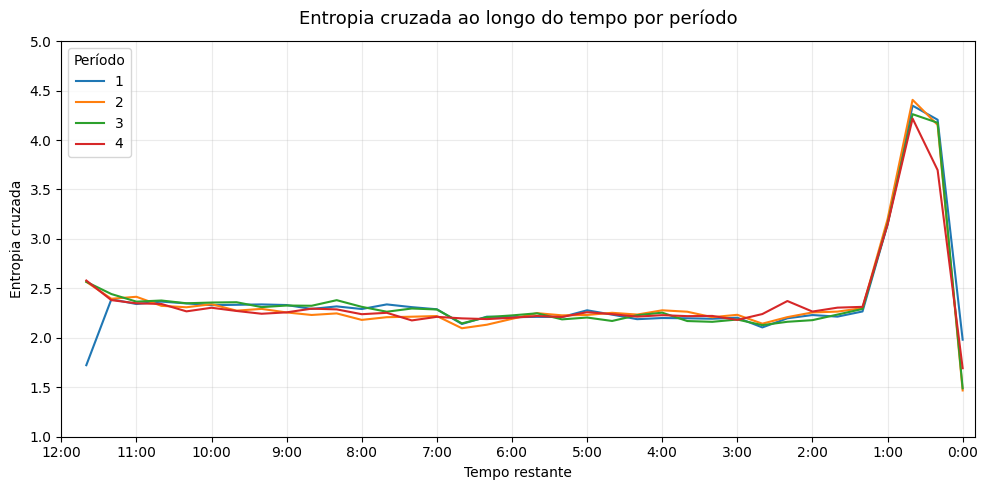

In [89]:
fig, ax = plt.subplots(1, 1, figsize = (10, 5))

df_resultados4\
.query("context_size == 5 & embedding_layer_size == 32 & num_hidden_neurons == 50 & num_layers == 5 & dropout_rate == 0 & layer_norm == 0 & set_covariables == 56")\
.query("period <= 4")\
.assign(t1 = lambda df: df["cat_time"].str.split("-").str[0].astype("int")/10)\
.pivot_table(index = ["t1"], columns = "period", values = "cross_entropy_mean")\
.plot(ax = ax)

ax.set_ylim(1, 5)
ax.invert_xaxis()
ax.set_xlim(720, -10)  # 12:00 até 0:00
ax.set_xticks([720, 660, 600, 540, 480, 420, 360, 300, 240, 180, 120, 60, 0])
ax.xaxis.set_major_formatter(mticker.FuncFormatter(format_time_seconds))

# Grade e legenda
ax.grid(True, alpha=0.25)
ax.legend(title="Período", frameon=True)

# Título e rótulos
ax.set_title("Entropia cruzada ao longo do tempo por período",
             fontsize = 13,pad = 12)

ax.set_xlabel("Tempo restante")
ax.set_ylabel("Entropia cruzada")
#ax.axhline(1 - (1/600), zorder = -3)
plt.tight_layout()



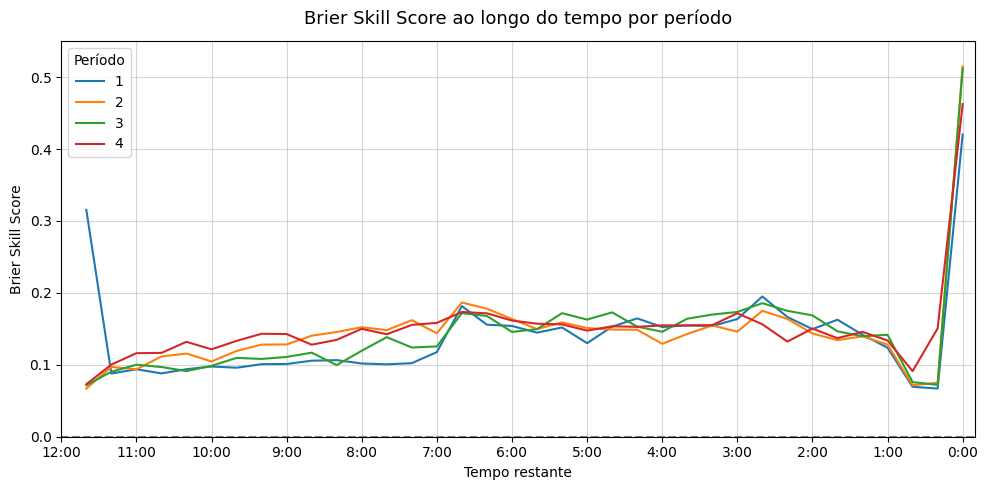

In [90]:
fig, ax = plt.subplots(1, 1, figsize = (10, 5))

df_resultados4\
.query("context_size == 5 & embedding_layer_size == 32 & num_hidden_neurons == 50 & num_layers == 5 & dropout_rate == 0 & layer_norm == 0 & set_covariables == 56")\
.query("period <= 4")\
.assign(t1 = lambda df: df["cat_time"].str.split("-").str[0].astype("int")/10)\
.pivot_table(index = ["t1"], columns = "period", values = "bss_mean")\
.plot(ax = ax)

ax.set_ylim(0, 0.55)
ax.invert_xaxis()
ax.set_xlim(720, -10)  # 12:00 até 0:00
ax.set_xticks([720, 660, 600, 540, 480, 420, 360, 300, 240, 180, 120, 60, 0])
ax.xaxis.set_major_formatter(mticker.FuncFormatter(format_time_seconds))

# Grade e legenda
ax.grid(True, alpha=0.5)
ax.legend(title="Período", frameon=True)

# Título e rótulos
ax.set_title("Brier Skill Score ao longo do tempo por período",
             fontsize = 13,pad = 12)

ax.set_xlabel("Tempo restante")
ax.set_ylabel("Brier Skill Score")
ax.axhline(0, zorder = -3, linestyle = '--', color = 'gray')
plt.tight_layout()



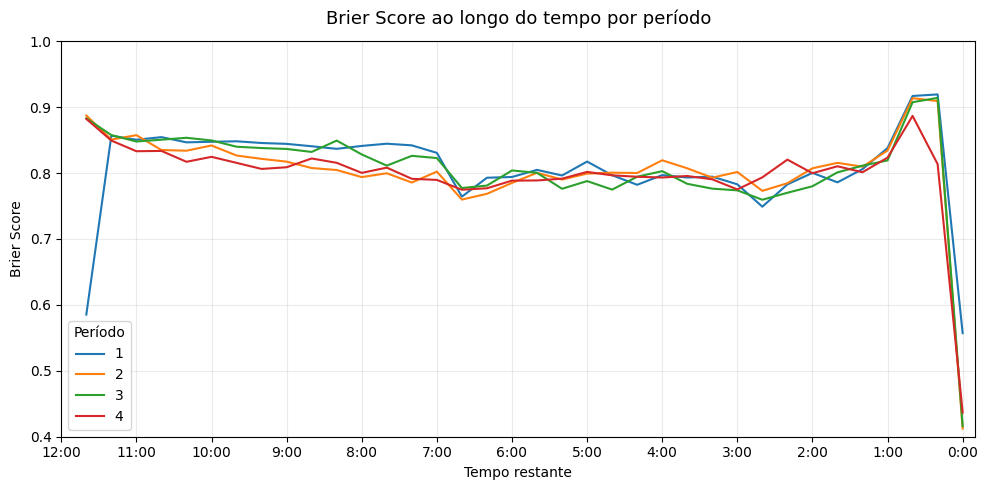

In [91]:
fig, ax = plt.subplots(1, 1, figsize = (10, 5))

df_resultados4\
.query("context_size == 5 & embedding_layer_size == 32 & num_hidden_neurons == 50 & num_layers == 5 & dropout_rate == 0 & layer_norm == 0 & set_covariables == 56")\
.query("period <= 4")\
.assign(t1 = lambda df: df["cat_time"].str.split("-").str[0].astype("int")/10)\
.pivot_table(index = ["t1"], columns = "period", values = "bs_mean")\
.plot(ax = ax)

ax.set_ylim(0.4, 1)
ax.invert_xaxis()
ax.set_xlim(720, -10)  # 12:00 até 0:00
ax.set_xticks([720, 660, 600, 540, 480, 420, 360, 300, 240, 180, 120, 60, 0])
ax.xaxis.set_major_formatter(mticker.FuncFormatter(format_time_seconds))

# Grade e legenda
ax.grid(True, alpha=0.25)
ax.legend(title="Período", frameon=True)

# Título e rótulos
ax.set_title("Brier Score ao longo do tempo por período",
             fontsize = 13,pad = 12)

ax.set_xlabel("Tempo restante")
ax.set_ylabel("Brier Score")

# Grade leve para leitura
ax.grid(True, alpha=0.25)

#ax.axhline(1 - (1/600), zorder = -3)
plt.tight_layout()



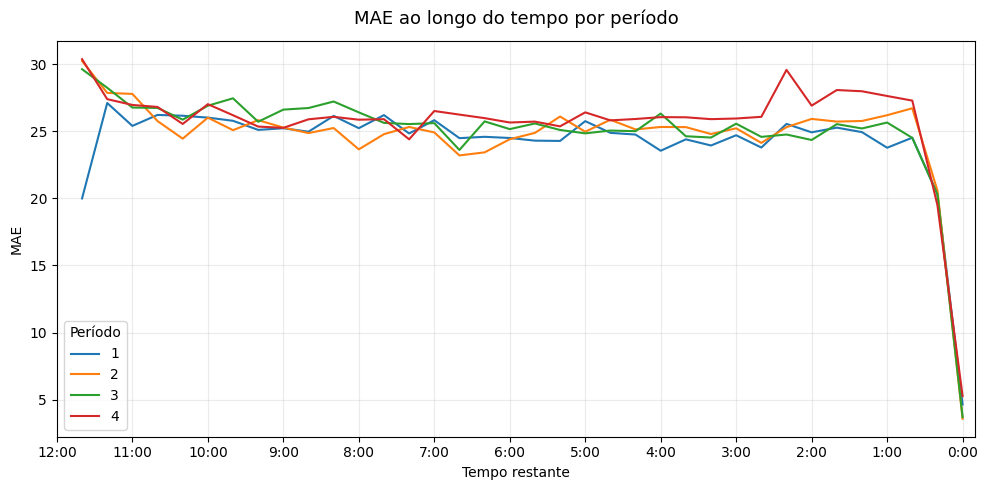

In [92]:
fig, ax = plt.subplots(1, 1, figsize = (10, 5))

df_resultados4\
.query("context_size == 5 & embedding_layer_size == 32 & num_hidden_neurons == 50 & num_layers == 5 & dropout_rate == 0 & layer_norm == 0 & set_covariables == 56")\
.query("period <= 4")\
.assign(t1 = lambda df: df["cat_time"].str.split("-").str[0].astype("int")/10)\
.pivot_table(index = ["t1"], columns = "period", values = "mae_mean")\
.plot(ax = ax)

#ax.set_ylim(0.4, 1)
ax.invert_xaxis()
ax.set_xlim(720, -10)  # 12:00 até 0:00
ax.set_xticks([720, 660, 600, 540, 480, 420, 360, 300, 240, 180, 120, 60, 0])
ax.xaxis.set_major_formatter(mticker.FuncFormatter(format_time_seconds))

# Grade e legenda
ax.grid(True, alpha=0.25)
ax.legend(title="Período", frameon=True)

# Título e rótulos
ax.set_title("MAE ao longo do tempo por período",
             fontsize = 13,pad = 12)

ax.set_xlabel("Tempo restante")
ax.set_ylabel("MAE")

# Grade leve para leitura
ax.grid(True, alpha=0.25)

#ax.axhline(1 - (1/600), zorder = -3)
plt.tight_layout()



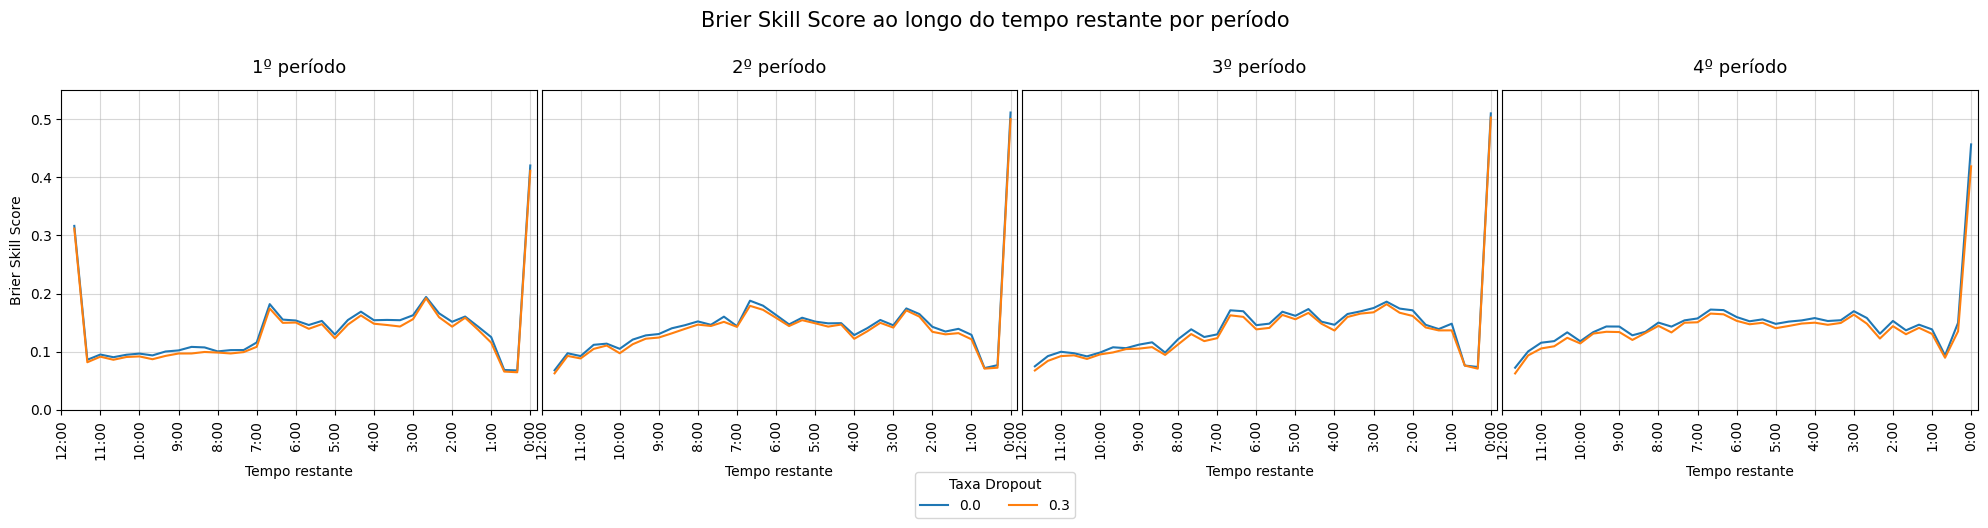

In [93]:
fig, ax = plt.subplots(1, 4, figsize = (20, 5))

for i in range(4):
    df_resultados4\
    .query("context_size == 5 & embedding_layer_size == 32 & num_hidden_neurons == 50 & layer_norm == 0 & num_layers == 3 & set_covariables == 56")\
    .query("period == (@i + 1)")\
    .assign(t1 = lambda df: df["cat_time"].str.split("-").str[0].astype("int")/10)\
    .pivot_table(index = "t1", columns = "dropout_rate", values = "bss_mean")\
    .plot(ax = ax[i], legend = False)

    ax[i].set_ylim(0, 0.55)
    ax[i].invert_xaxis()
    ax[i].set_xlim(720, -10)
    ax[i].set_xticks([720, 660, 600, 540, 480, 420, 360, 300, 240, 180, 120, 60, 0])
    ax[i].xaxis.set_major_formatter(mticker.FuncFormatter(format_time_seconds))
    ax[i].tick_params(axis = "x", labelrotation = 90)

    ax[i].grid(True, alpha=0.5)
    ax[i].set_title(f"{i+1}º período", fontsize=13, pad=12)
    ax[i].set_xlabel("Tempo restante")

    if i == 0:
        ax[i].set_ylabel("Brier Skill Score")
        ax[i].tick_params(axis="y", labelleft=True)
    else:
        ax[i].set_ylabel("")
        ax[i].tick_params(axis="y", left=False, labelleft=False)

# título geral
fig.suptitle("Brier Skill Score ao longo do tempo restante por período", fontsize=15, y=0.98)

# legenda única embaixo
handles, labels = ax[0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    title="Taxa Dropout",
    loc="lower center",
    ncol=3,
    frameon=True,
    bbox_to_anchor=(0.5, -0.05)
)

plt.tight_layout()
fig.subplots_adjust(wspace=0.01, top=0.82, bottom=0.18)
plt.show()

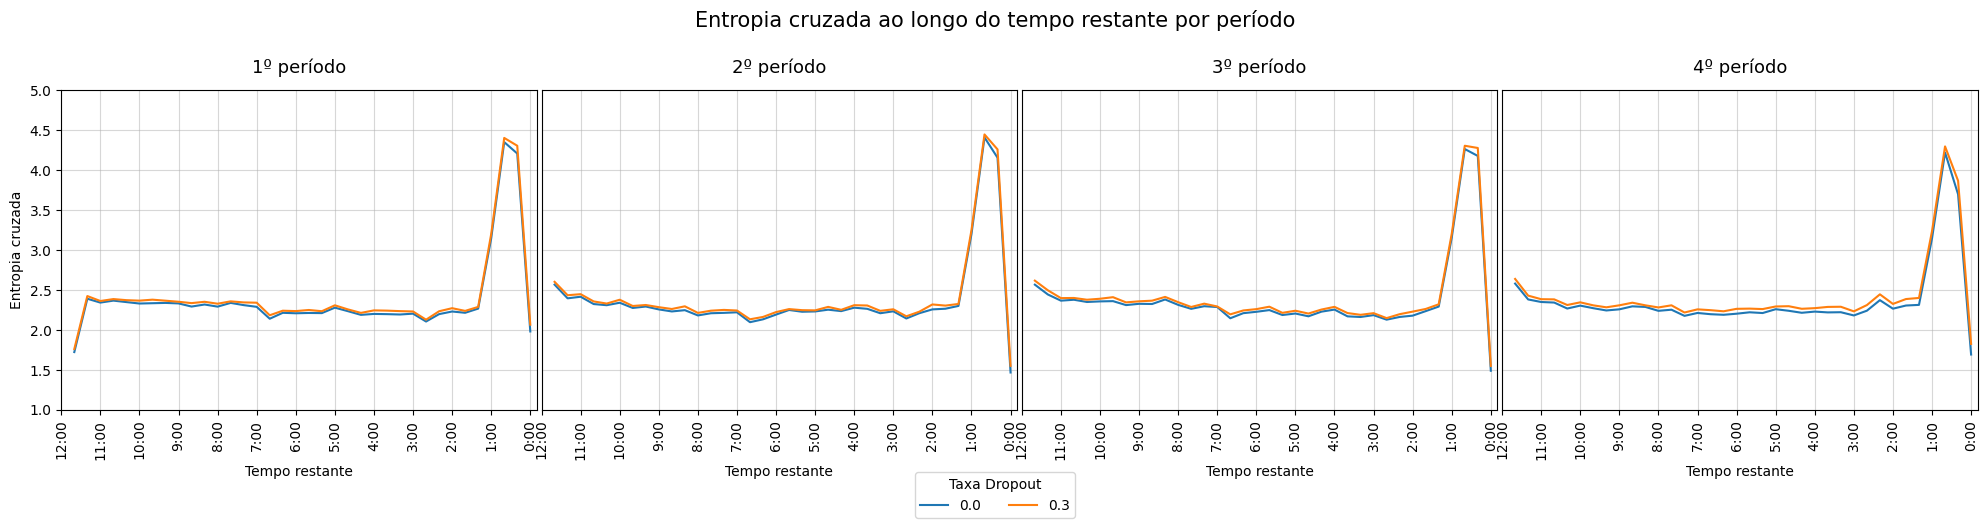

In [94]:
fig, ax = plt.subplots(1, 4, figsize = (20, 5))

for i in range(4):
    df_resultados4\
    .query("context_size == 5 & embedding_layer_size == 32 & num_hidden_neurons == 50 & num_layers == 5 & layer_norm == 0 & set_covariables == 56")\
    .query("period == (@i + 1)")\
    .assign(t1 = lambda df: df["cat_time"].str.split("-").str[0].astype("int")/10)\
    .pivot_table(index = "t1", columns = "dropout_rate", values = "cross_entropy_mean")\
    .plot(ax = ax[i], legend=False)

    ax[i].set_ylim(1, 5)
    ax[i].invert_xaxis()
    ax[i].set_xlim(720, -10)
    ax[i].set_xticks([720, 660, 600, 540, 480, 420, 360, 300, 240, 180, 120, 60, 0])
    ax[i].xaxis.set_major_formatter(mticker.FuncFormatter(format_time_seconds))
    ax[i].tick_params(axis = "x", labelrotation = 90)

    ax[i].grid(True, alpha=0.5)
    ax[i].set_title(f"{i+1}º período", fontsize=13, pad=12)
    ax[i].set_xlabel("Tempo restante")

    if i == 0:
        ax[i].set_ylabel("Entropia cruzada")
        ax[i].tick_params(axis="y", labelleft=True)
    else:
        ax[i].set_ylabel("")
        ax[i].tick_params(axis="y", left=False, labelleft=False)

# título geral
fig.suptitle("Entropia cruzada ao longo do tempo restante por período", fontsize=15, y=0.98)

# legenda única embaixo
handles, labels = ax[0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    title="Taxa Dropout",
    loc="lower center",
    ncol=3,
    frameon=True,
    bbox_to_anchor=(0.5, -0.05)
)

plt.tight_layout()
fig.subplots_adjust(wspace=0.01, top=0.82, bottom=0.18)
plt.show()

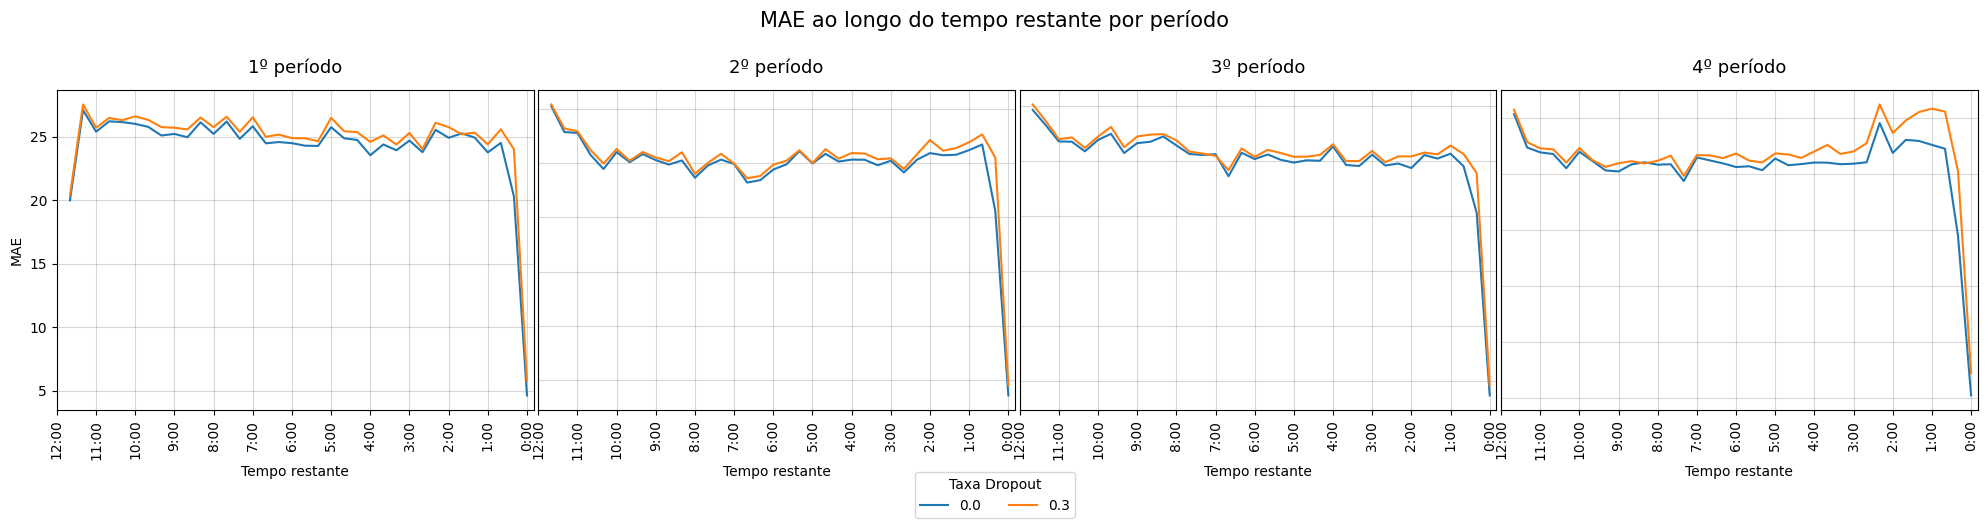

In [95]:
fig, ax = plt.subplots(1, 4, figsize = (20, 5))

for i in range(4):
    df_resultados4\
    .query("context_size == 5 & embedding_layer_size == 32 & num_hidden_neurons == 50 & num_layers == 5 & layer_norm == 0 & set_covariables == 56")\
    .query("period == (@i + 1)")\
    .assign(t1 = lambda df: df["cat_time"].str.split("-").str[0].astype("int")/10)\
    .pivot_table(index = "t1", columns = "dropout_rate", values = "mae_mean")\
    .plot(ax = ax[i], legend=False)

    #ax[i].set_ylim(1, 5)
    ax[i].invert_xaxis()
    ax[i].set_xlim(720, -10)
    ax[i].set_xticks([720, 660, 600, 540, 480, 420, 360, 300, 240, 180, 120, 60, 0])
    ax[i].xaxis.set_major_formatter(mticker.FuncFormatter(format_time_seconds))
    ax[i].tick_params(axis = "x", labelrotation = 90)

    ax[i].grid(True, alpha=0.5)
    ax[i].set_title(f"{i+1}º período", fontsize=13, pad=12)
    ax[i].set_xlabel("Tempo restante")

    if i == 0:
        ax[i].set_ylabel("MAE")
        ax[i].tick_params(axis="y", labelleft=True)
    else:
        ax[i].set_ylabel("")
        ax[i].tick_params(axis="y", left=False, labelleft=False)

# título geral
fig.suptitle("MAE ao longo do tempo restante por período", fontsize=15, y=0.98)

# legenda única embaixo
handles, labels = ax[0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    title="Taxa Dropout",
    loc="lower center",
    ncol=3,
    frameon=True,
    bbox_to_anchor=(0.5, -0.05)
)

plt.tight_layout()
fig.subplots_adjust(wspace=0.01, top=0.82, bottom=0.18)
plt.show()

In [ ]:
df_resultados4

,period,cat_time,context_size,embedding_layer_size,set_covariables,num_hidden_neurons,num_layers,dropout_rate,layer_norm,bs_mean,...,cross_entropy_mean,cross_entropy_std,reliability_erro_mean,reliability_erro_std,resolution_poder_mean,resolution_poder_std,uncertainty_caos_mean,uncertainty_caos_std,bss_mean,bss_std
0,1,0-200,5,32,56,50,3,0.0,False,0.557226,...,1.970119,0.062858,0.069017,0.005957,0.464558,0.021064,0.961000,0.004742,0.420151,0.017522
1,1,0-200,5,32,56,50,3,0.0,True,0.578569,...,2.031251,0.058817,0.078699,0.006795,0.452298,0.013533,0.961000,0.004742,0.397950,0.010495
2,1,0-200,5,32,56,50,3,0.3,False,0.565847,...,2.053963,0.066050,0.050749,0.012371,0.434223,0.017443,0.961000,0.004742,0.411188,0.017087
3,1,0-200,5,32,56,50,3,0.3,True,0.588158,...,2.074379,0.064216,0.076923,0.006596,0.440144,0.016984,0.961000,0.004742,0.387969,0.014445
4,1,0-200,5,32,56,50,5,0.0,False,0.557114,...,1.981051,0.057680,0.062191,0.002257,0.457557,0.016836,0.961000,0.004742,0.420256,0.015428
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2539,5,800-1000,5,64,56,50,3,0.3,True,0.841817,...,2.444876,0.239649,0.116144,0.054165,0.186152,0.051289,0.893785,0.037694,0.056988,0.036563
2540,5,800-1000,5,64,56,50,5,0.0,False,0.833521,...,2.370768,0.229025,0.126218,0.044534,0.197989,0.022920,0.893785,0.037694,0.065885,0.048374
2541,5,800-1000,5,64,56,50,5,0.0,True,0.828332,...,2.308110,0.166414,0.123737,0.034761,0.200028,0.044744,0.893785,0.037694,0.072068,0.045839
2542,5,800-1000,5,64,56,50,5,0.3,False,0.842930,...,2.493617,0.299740,0.139245,0.055141,0.205893,0.047207,0.893785,0.037694,0.056059,0.031230


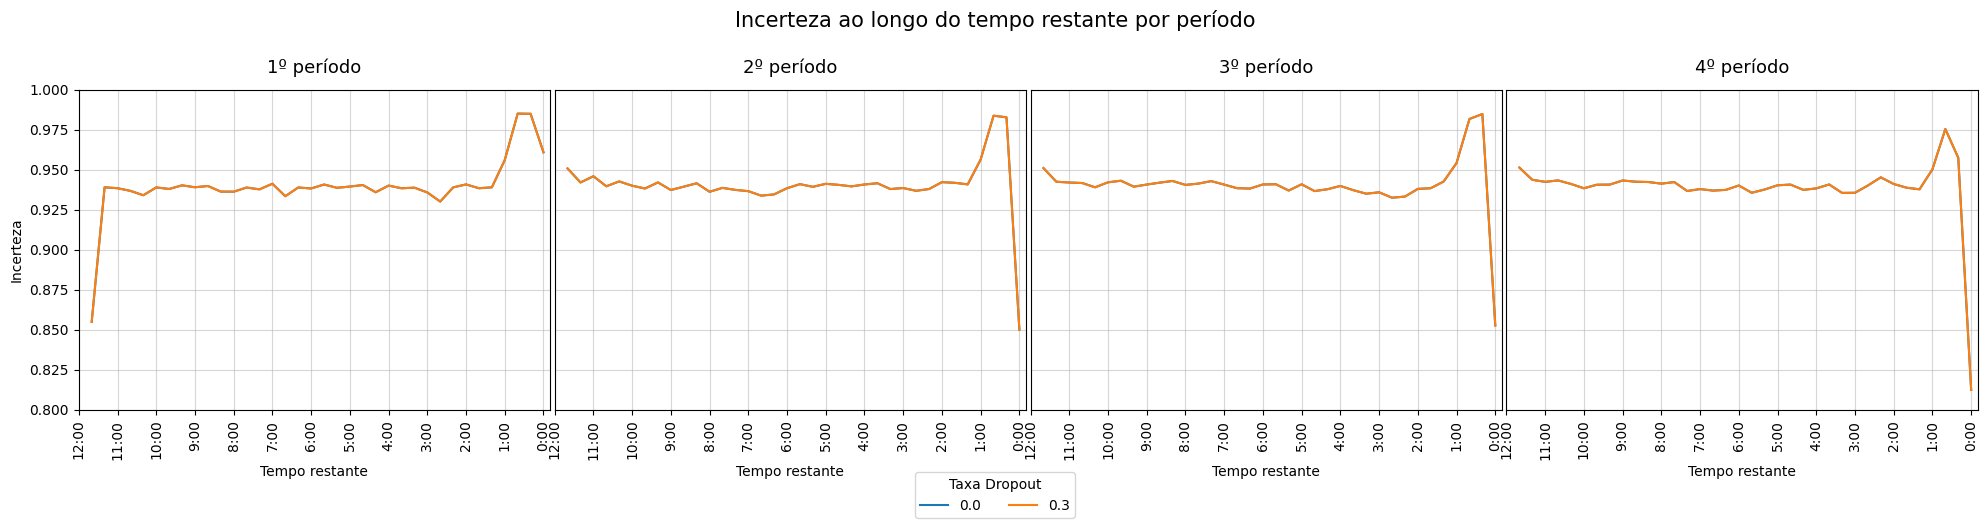

In [96]:
fig, ax = plt.subplots(1, 4, figsize = (20, 5))

for i in range(4):
    df_resultados4\
    .query("context_size == 5 & embedding_layer_size == 32 & num_hidden_neurons == 50 & num_layers == 3 & layer_norm == 0 & set_covariables == 56")\
    .query("period == (@i + 1)")\
    .assign(t1 = lambda df: df["cat_time"].str.split("-").str[0].astype("int")/10)\
    .pivot_table(index = "t1", columns = "dropout_rate", values = "uncertainty_caos_mean")\
    .plot(ax = ax[i], legend = False)

    ax[i].set_ylim(0.8, 1)
    ax[i].invert_xaxis()
    ax[i].set_xlim(720, -10)
    ax[i].set_xticks([720, 660, 600, 540, 480, 420, 360, 300, 240, 180, 120, 60, 0])
    ax[i].xaxis.set_major_formatter(mticker.FuncFormatter(format_time_seconds))
    ax[i].tick_params(axis = "x", labelrotation = 90)

    ax[i].grid(True, alpha=0.5)
    ax[i].set_title(f"{i+1}º período", fontsize=13, pad=12)
    ax[i].set_xlabel("Tempo restante")

    if i == 0:
        ax[i].set_ylabel("Incerteza")
        ax[i].tick_params(axis="y", labelleft=True)
    else:
        ax[i].set_ylabel("")
        ax[i].tick_params(axis="y", left=False, labelleft=False)

# título geral
fig.suptitle("Incerteza ao longo do tempo restante por período", fontsize=15, y=0.98)

# legenda única embaixo
handles, labels = ax[0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    title="Taxa Dropout",
    loc="lower center",
    ncol=3,
    frameon=True,
    bbox_to_anchor=(0.5, -0.05)
)

plt.tight_layout()
fig.subplots_adjust(wspace=0.01, top=0.82, bottom=0.18)
plt.show()

In [133]:
df_resultados4

,period,cat_time,context_size,embedding_layer_size,set_covariables,num_hidden_neurons,num_layers,dropout_rate,layer_norm,bs_mean,...,mae_mean,mae_std,reliability_erro_mean,reliability_erro_std,resolution_poder_mean,resolution_poder_std,uncertainty_caos_mean,uncertainty_caos_std,bss_mean,bss_std
0,1,0-200,5,32,56,50,3,0.0,False,0.557226,...,4.379625,0.277827,0.072133,0.006086,0.464558,0.021064,0.961000,0.004742,0.420151,0.017522
1,1,0-200,5,32,56,50,3,0.0,True,0.578569,...,4.245528,0.308918,0.081245,0.006646,0.452298,0.013533,0.961000,0.004742,0.397950,0.010495
2,1,0-200,5,32,56,50,3,0.3,False,0.565847,...,5.774449,0.435733,0.051978,0.012282,0.434223,0.017443,0.961000,0.004742,0.411188,0.017087
3,1,0-200,5,32,56,50,3,0.3,True,0.588158,...,5.016447,0.316895,0.078139,0.006499,0.440144,0.016984,0.961000,0.004742,0.387969,0.014445
4,1,0-200,5,32,56,50,5,0.0,False,0.557114,...,4.631332,0.283326,0.064758,0.001800,0.457557,0.016836,0.961000,0.004742,0.420256,0.015428
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2539,5,800-1000,5,64,56,50,3,0.3,True,0.841817,...,32.446670,3.357638,0.143570,0.068261,0.186152,0.051289,0.893785,0.037694,0.056988,0.036563
2540,5,800-1000,5,64,56,50,5,0.0,False,0.833521,...,31.052278,5.560376,0.149867,0.051572,0.197989,0.022920,0.893785,0.037694,0.065885,0.048374
2541,5,800-1000,5,64,56,50,5,0.0,True,0.828332,...,30.311491,4.485039,0.149581,0.046421,0.200028,0.044744,0.893785,0.037694,0.072068,0.045839
2542,5,800-1000,5,64,56,50,5,0.3,False,0.842930,...,33.371867,4.553611,0.163262,0.060260,0.205893,0.047207,0.893785,0.037694,0.056059,0.031230


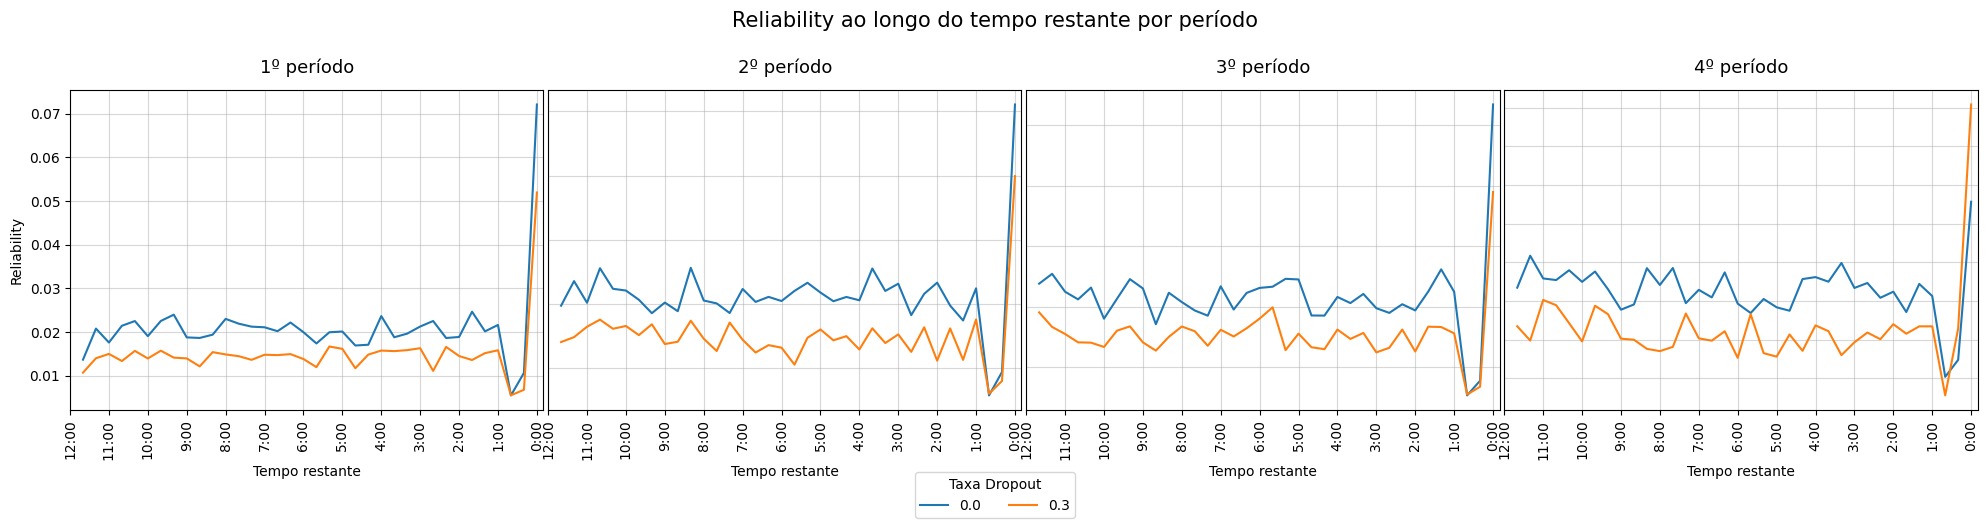

In [134]:
fig, ax = plt.subplots(1, 4, figsize = (20, 5))

for i in range(4):
    df_resultados4\
    .query("context_size == 5 & embedding_layer_size == 32 & num_hidden_neurons == 50 & num_layers == 3 & layer_norm == 0 & set_covariables == 56")\
    .query("period == (@i + 1)")\
    .assign(t1 = lambda df: df["cat_time"].str.split("-").str[0].astype("int")/10)\
    .pivot_table(index = "t1", columns = "dropout_rate", values = "reliability_erro_mean")\
    .plot(ax = ax[i], legend = False)

    #ax[i].set_ylim(0.8, 1)
    ax[i].invert_xaxis()
    ax[i].set_xlim(720, -10)
    ax[i].set_xticks([720, 660, 600, 540, 480, 420, 360, 300, 240, 180, 120, 60, 0])
    ax[i].xaxis.set_major_formatter(mticker.FuncFormatter(format_time_seconds))
    ax[i].tick_params(axis = "x", labelrotation = 90)

    ax[i].grid(True, alpha=0.5)
    ax[i].set_title(f"{i+1}º período", fontsize=13, pad=12)
    ax[i].set_xlabel("Tempo restante")

    if i == 0:
        ax[i].set_ylabel("Reliability")
        ax[i].tick_params(axis="y", labelleft=True)
    else:
        ax[i].set_ylabel("")
        ax[i].tick_params(axis="y", left=False, labelleft=False)

# título geral
fig.suptitle("Reliability ao longo do tempo restante por período", fontsize=15, y=0.98)

# legenda única embaixo
handles, labels = ax[0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    title="Taxa Dropout",
    loc="lower center",
    ncol=3,
    frameon=True,
    bbox_to_anchor=(0.5, -0.05)
)

plt.tight_layout()
fig.subplots_adjust(wspace=0.01, top=0.82, bottom=0.18)
plt.show()

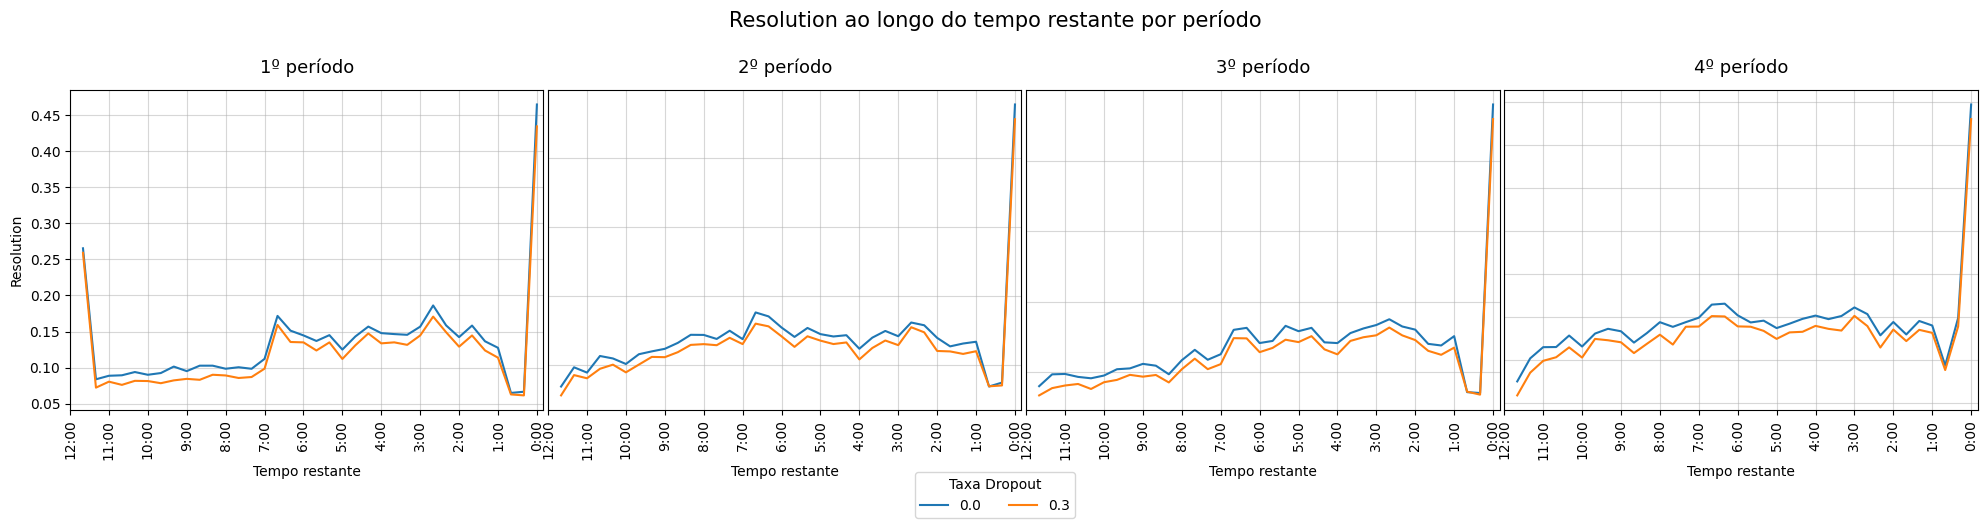

In [136]:
fig, ax = plt.subplots(1, 4, figsize = (20, 5))

for i in range(4):
    df_resultados4\
    .query("context_size == 5 & embedding_layer_size == 32 & num_hidden_neurons == 50 & num_layers == 3 & layer_norm == 0 & set_covariables == 56")\
    .query("period == (@i + 1)")\
    .assign(t1 = lambda df: df["cat_time"].str.split("-").str[0].astype("int")/10)\
    .pivot_table(index = "t1", columns = "dropout_rate", values = "resolution_poder_mean")\
    .plot(ax = ax[i], legend = False)

    #ax[i].set_ylim(0.8, 1)
    ax[i].invert_xaxis()
    ax[i].set_xlim(720, -10)
    ax[i].set_xticks([720, 660, 600, 540, 480, 420, 360, 300, 240, 180, 120, 60, 0])
    ax[i].xaxis.set_major_formatter(mticker.FuncFormatter(format_time_seconds))
    ax[i].tick_params(axis = "x", labelrotation = 90)

    ax[i].grid(True, alpha=0.5)
    ax[i].set_title(f"{i+1}º período", fontsize=13, pad=12)
    ax[i].set_xlabel("Tempo restante")

    if i == 0:
        ax[i].set_ylabel("Resolution")
        ax[i].tick_params(axis="y", labelleft=True)
    else:
        ax[i].set_ylabel("")
        ax[i].tick_params(axis="y", left=False, labelleft=False)

# título geral
fig.suptitle("Resolution ao longo do tempo restante por período", fontsize=15, y=0.98)

# legenda única embaixo
handles, labels = ax[0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    title="Taxa Dropout",
    loc="lower center",
    ncol=3,
    frameon=True,
    bbox_to_anchor=(0.5, -0.05)
)

plt.tight_layout()
fig.subplots_adjust(wspace=0.01, top=0.82, bottom=0.18)
plt.show()

In [ ]:
# df_check_uncertainty = df_murphy_decomposition_by_time\
# .query("context_size == 5 & embedding_layer_size == 32 & num_hidden_neurons == 50 & num_layers == 3 & layer_norm == 0 & set_covariables == 56 & dropout_rate == 0 & layer_norm == 0")\
# .query("period <= 4")\
# .groupby(["seasondata", "period", "cat_time"], observed=True, as_index=False)\
# .agg(
#     uncertainty = ("uncertainty_caos", "sum"),
#     n_classes = ("token_id", "nunique"),
#     n_tokens_observed = ("frequencia", lambda x: (x > 0).sum()),
#     n_obs = ("frequencia", "sum"),
#     max_freq = ("frequencia", "max")
# )\
# .assign(
#     top1_share = lambda df: df["max_freq"] / df["n_obs"]
# )

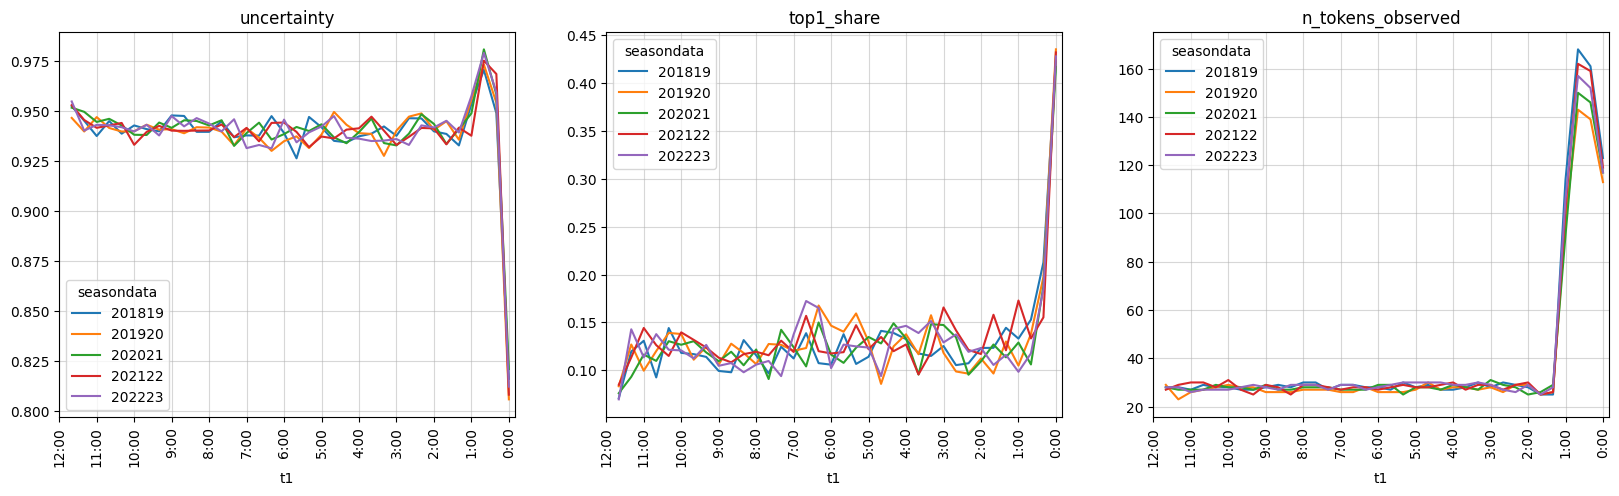

In [ ]:
# fig, ax = plt.subplots(1, 3, figsize = (20, 5))

# df_check_uncertainty\
# .query("period == 4")\
# .sort_values("cat_time")\
# [["seasondata", "period", "cat_time", "uncertainty", "n_obs", "n_tokens_observed", "top1_share"]]\
# .assign(t1 = lambda df: df["cat_time"].str.split("-").str[0].astype("int")/10)\
# .sort_values("t1", ascending = False)\
# .pivot_table(index = ["t1"], columns = "seasondata", values = "uncertainty")\
# .plot(title= "uncertainty", ax = ax[0])

# i = 0
# #ax[i].set_ylim(0.8, 1)
# ax[i].invert_xaxis()
# ax[i].set_xlim(720, -10)
# ax[i].set_xticks([720, 660, 600, 540, 480, 420, 360, 300, 240, 180, 120, 60, 0])
# ax[i].xaxis.set_major_formatter(mticker.FuncFormatter(format_time_seconds))
# ax[i].tick_params(axis = "x", labelrotation = 90)

# ax[i].grid(True, alpha=0.5)

# df_check_uncertainty\
# .query("period == 4")\
# .sort_values("cat_time")\
# [["seasondata", "period", "cat_time", "uncertainty", "n_obs", "n_tokens_observed", "top1_share"]]\
# .assign(t1 = lambda df: df["cat_time"].str.split("-").str[0].astype("int")/10)\
# .sort_values("t1", ascending = False)\
# .pivot_table(index = ["t1"], columns = "seasondata", values = "top1_share")\
# .plot(title= "top1_share", ax = ax[1])

# i = 1
# #ax[i].set_ylim(0.8, 1)
# ax[i].invert_xaxis()
# ax[i].set_xlim(720, -10)
# ax[i].set_xticks([720, 660, 600, 540, 480, 420, 360, 300, 240, 180, 120, 60, 0])
# ax[i].xaxis.set_major_formatter(mticker.FuncFormatter(format_time_seconds))
# ax[i].tick_params(axis = "x", labelrotation = 90)

# ax[i].grid(True, alpha=0.5)

# df_check_uncertainty\
# .query("period == 4")\
# .sort_values("cat_time")\
# [["seasondata", "period", "cat_time", "uncertainty", "n_obs", "n_tokens_observed", "top1_share"]]\
# .assign(t1 = lambda df: df["cat_time"].str.split("-").str[0].astype("int")/10)\
# .sort_values("t1", ascending = False)\
# .pivot_table(index = ["t1"], columns = "seasondata", values = "n_tokens_observed")\
# .plot(title= "n_tokens_observed", ax = ax[2])

# i = 2
# #ax[i].set_ylim(0.8, 1)
# ax[i].invert_xaxis()
# ax[i].set_xlim(720, -10)
# ax[i].set_xticks([720, 660, 600, 540, 480, 420, 360, 300, 240, 180, 120, 60, 0])
# ax[i].xaxis.set_major_formatter(mticker.FuncFormatter(format_time_seconds))
# ax[i].tick_params(axis = "x", labelrotation = 90)

# ax[i].grid(True, alpha=0.5)

# plt.show()
# # \
# # .pivot_table(index = "t1", columns = "dropout_rate", values = "uncertainty_caos_mean")

In [132]:
df_resultados3.query("cat_time in ['0-200'] & period == 4")\
.pivot_table(index = ["period", "cat_time", "context_size", "embedding_layer_size", "set_covariables", "num_hidden_neurons", "num_layers", "dropout_rate", "layer_norm"], columns =  "seasondata", values = "bss")\
.reset_index()

seasondata,period,cat_time,context_size,embedding_layer_size,set_covariables,num_hidden_neurons,num_layers,dropout_rate,layer_norm,201819,201920,202021,202122,202223
0,4,0-200,5,32,56,50,3,0.0,False,0.489269,0.455698,0.441935,0.436769,0.458280
1,4,0-200,5,32,56,50,3,0.0,True,0.405287,0.402759,0.389542,0.375230,0.399493
2,4,0-200,5,32,56,50,3,0.3,False,0.435314,0.418239,0.413271,0.390517,0.436185
3,4,0-200,5,32,56,50,3,0.3,True,0.388440,0.385697,0.374225,0.363432,0.375014
4,4,0-200,5,32,56,50,5,0.0,False,0.492690,0.469275,0.444912,0.437749,0.468068
5,4,0-200,5,32,56,50,5,0.0,True,0.413906,0.405308,0.380853,0.386914,0.406339
6,4,0-200,5,32,56,50,5,0.3,False,0.451637,0.417181,0.405254,0.397595,0.429190
7,4,0-200,5,32,56,50,5,0.3,True,0.375703,0.382600,0.366152,0.358696,0.372789
8,4,0-200,5,64,56,50,3,0.0,False,0.475892,0.425537,0.429370,0.423156,0.443414
9,4,0-200,5,64,56,50,3,0.0,True,0.404105,0.393230,0.383099,0.367613,0.389213
